# Introduction to `SpatialData` objects

**Day 1 · Session 1**

Spatial omics data is not one table. It is a microscopy image, a set of segmentation masks,
a million individual transcript locations, cell boundaries as polygons, and a cell-by-gene
matrix — five different kinds of object that all have to agree on where things are.
`SpatialData` is the container that keeps them consistent.

### What you will be able to do afterwards

- Name the five element types, and say which Python class each one is
- Find your way around a `SpatialData` object you have never seen before
- Render an image with cell boundaries on top, colour cells by a measurement, and crop to a
  region of interest

## Setup

The data is already on the server, converted to the SpatialData Zarr format, and
**read-only**. Do not hardcode the path — `paths.py` in the repository root resolves it,
and the same notebook then works on your own laptop later if you set `PHYSALIA_DATA`.

In [1]:
%matplotlib inline

import pathlib
import sys

# Find the repository root (the directory holding paths.py) and make it importable.
# Safe to re-run: unlike %cd, this does not move anywhere.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401  - registers the .pl accessor

import paths

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
sdata

no parent found for <ome_zarr.reader.Label object at 0x16e82cd70>: None


no parent found for <ome_zarr.reader.Label object at 0x16e8d66f0>: None


SpatialData object, with associated Zarr store: /opt/workshop/data/xenium_breast_2fov.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 3529, 5792), (4, 1764, 2896), (4, 882, 1448), (4, 441, 724), (4, 220, 362)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3529, 5792), (1764, 2896), (882, 1448), (441, 724), (220, 362)
│     └── 'nucleus_labels': DataTree[yx] (3529, 5792), (1764, 2896), (882, 1448), (441, 724), (220, 362)
├── Points
│     └── 'transcripts': DataFrame with shape: (1113950, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (7275, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (7312, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (7275, 280)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

That text representation is the first thing to learn to read. It lists every *element* in
the object, grouped by type, with its shape, and the coordinate systems those elements live
in.

This is a 10x Xenium run: a two-field-of-view crop of a human breast cancer section with a
280-gene panel — 7,275 cells and 1.1 million transcripts. Small enough that all of us can
hold it open on one shared machine, real enough to show every artifact we will discuss
after the break.

## 1. The five element types

A `SpatialData` object is a container for **images**, **labels**, **points**, **shapes** and
**tables**. Each one is called an *element*.

<img src="resources/elements.png" alt="the SpatialData element model" style="max-width: 800px;">

`spatialdata` deliberately does **not** invent new classes for these. It reuses the standard
objects of the imaging and geospatial Python communities, so anything you already know how
to do to a `GeoDataFrame` or an `AnnData` still works:

| Element | Python class | In this dataset |
|---|---|---|
| Images | `xarray.DataArray`, or `DataTree` if multiscale | `morphology_focus` — the 4-channel stain |
| Labels | `xarray.DataArray`, or `DataTree` if multiscale | `cell_labels`, `nucleus_labels` — segmentation masks |
| Points | `dask.dataframe.DataFrame` (lazy) | `transcripts` — one row per detection |
| Shapes | `geopandas.GeoDataFrame` | `cell_boundaries`, `nucleus_boundaries` |
| Tables | `anndata.AnnData` | `table` — 7,275 cells x 280 genes |

A note on jargon: a *shapes element* is the whole dataframe of all cells. One cell is a
**row** in it, not an element of its own.

In [3]:
for kind in ("images", "labels", "points", "shapes", "tables"):
    print(f"{kind:8s} {list(getattr(sdata, kind))}")

images   ['morphology_focus']
labels   ['cell_labels', 'nucleus_labels']
points   ['transcripts']
shapes   ['cell_boundaries', 'nucleus_boundaries']
tables   ['table']


## 2. Images and labels

Images and labels are both `xarray` objects on a regular pixel grid. The difference is that
images carry a channel dimension `c` and labels never do — a labels element stores one
integer per pixel: the ID of the object that pixel belongs to, `0` for background.

Large images are stored **multiscale**, as a `DataTree`: the same image at several
resolutions. Plotting code then reads the resolution it actually needs instead of pulling
the full-size array off disk.

<img src="resources/image_pyramid.png" alt="multiscale image pyramid" style="max-width: 600px;">

In [4]:
image = sdata["morphology_focus"]
image

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 4, y: 3529, x: 5792)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 28kB 0.5 1.5 2.5 3.5 ... 3.526e+03 3.528e+03 3.528e+03
│         * x        (x) float64 46kB 0.5 1.5 2.5 3.5 ... 5.79e+03 5.79e+03 5.792e+03
│       Data variables:
│           image    (c, y, x) uint16 164MB dask.array<chunksize=(1, 3529, 4096), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 4, y: 1764, x: 2896)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 14kB 1.0 3.001 5.001 ... 3.524e+03 3.526e+03 3.528e+03
│         * x        (x) float64 23kB 1.0 3.0 5.0 7.0 ... 5.787e+03 5.789e+03 5.791e+03
│       Data variables:
│           image    (c, y, x) uint16 41MB dask.array<chunksize=(1, 1764, 2896), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 4, y: 882, x: 1448)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 7kB 2.001 6.002 10.0 ... 3.519e+03 3.523e+03 3.527e+03
│         * x        (x) float64 12kB 2.0 6.0 10.0 14.0 ... 5.782e+03 5.786e+03 5.79e+03
│       Data variables:
│           image    (c, y, x) uint16 10MB dask.array<chunksize=(1, 882, 1448), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 4, y: 441, x: 724)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 4kB 4.001 12.0 20.01 ... 3.509e+03 3.517e+03 3.525e+03
│         * x        (x) float64 6kB 4.0 12.0 20.0 28.0 ... 5.772e+03 5.78e+03 5.788e+03
│       Data variables:
│           image    (c, y, x) uint16 3MB dask.array<chunksize=(1, 441, 724), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 4, y: 220, x: 362)
        Coordinates:
          * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
          * y        (y) float64 2kB 8.02 24.06 40.1 ... 3.489e+03 3.505e+03 3.521e+03
          * x        (x) float64 3kB 8.0 24.0 40.0 ... 5.752e+03 5.768e+03 5.784e+03
        Data variables:
            image    (c, y, x) uint16 637kB dask.array<chunksize=(1, 220, 362), meta=np.ndarray>

In [5]:
# The scales of the pyramid, each one half the size of the last
print(list(image.keys()))

# One scale is a plain xarray.DataArray with dimensions (c, y, x)
image["scale0"]["image"]

['scale0', 'scale1', 'scale2', 'scale3', 'scale4']


<xarray.DataArray 'image' (c: 4, y: 3529, x: 5792)> Size: 164MB
dask.array<from-zarr, shape=(4, 3529, 5792), dtype=uint16, chunksize=(1, 3529, 4096), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
  * y        (y) float64 28kB 0.5 1.5 2.5 3.5 ... 3.526e+03 3.528e+03 3.528e+03
  * x        (x) float64 46kB 0.5 1.5 2.5 3.5 ... 5.79e+03 5.79e+03 5.792e+03
Attributes:
    transform:  {'global': Identity }

**Channels have names, not numbers.** This is a Xenium multi-stain run, so asking for
"channel 0" will not work — you ask for `DAPI`.

In [6]:
list(image["scale0"]["image"].coords["c"].values)

[np.str_('DAPI'),
 np.str_('ATP1A1/CD45/E-Cadherin'),
 np.str_('18S'),
 np.str_('AlphaSMA/Vimentin')]

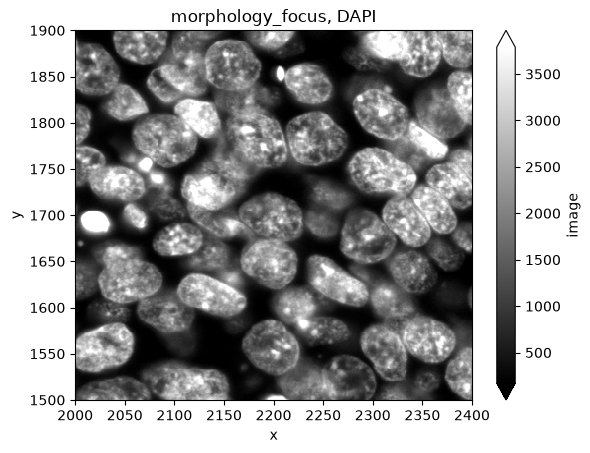

In [7]:
# A 400 x 400 pixel window of the DAPI channel at full resolution.
# Only this window is read from disk.
window = image["scale0"]["image"].sel(c="DAPI", x=slice(2000, 2400), y=slice(1500, 1900))
window.plot.imshow(cmap="gray", robust=True)
plt.title("morphology_focus, DAPI")
plt.show()

In [8]:
# Labels: same structure, no channel dimension
sdata["cell_labels"]["scale0"]["image"].dims

('y', 'x')

> **_Question:_** Nothing was read from disk until `.plot.imshow()` was called. Why is lazy
> the right default for this kind of data, and when would it cost you instead?

## 3. Shapes — `geopandas.GeoDataFrame`

Shapes elements hold geometry: cell boundaries as polygons, nucleus boundaries, or
centroids as circles. A
[`GeoDataFrame`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html)
is a `pandas.DataFrame` with a `geometry` column plus the geometric operations that come
with it.

In [9]:
gdf = sdata["cell_boundaries"]
gdf.head()

,geometry
aaaiikim-1,"POLYGON ((3.4 336.812, 2.763 337.025, 1.7 337...."
aaaljapa-1,"POLYGON ((3.825 348.075, 2.763 348.925, 2.55 3..."
aabhbgmg-1,"POLYGON ((6.163 334.263, 5.312 334.9, 4.675 33..."
aabpgobe-1,"POLYGON ((11.688 321.087, 11.05 321.3, 9.562 3..."
aacemgol-1,"POLYGON ((11.263 330.65, 11.05 330.863, 9.775 ..."


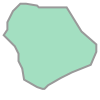

In [10]:
# A single cell boundary is a shapely polygon - Jupyter renders it directly
gdf.geometry.iloc[3]

Every `geopandas` operation is available. Area, for instance — which we will need after the
break, because cell area is one of the metrics that tells you whether a segmentation can be
trusted.

In [11]:
print(f"{len(gdf)} cells, median area {gdf.area.median():.1f} um^2")
gdf.area.describe()

7275 cells, median area 79.7 um^2


count    7275.000000
mean       87.800605
std        52.267638
min         3.996373
25%        49.637982
50%        79.700641
75%       115.058010
max       559.147134
dtype: float64

## 4. Points — `dask.dataframe.DataFrame`

Points are individual detections: one row per transcript, with a location, a gene name, and
a quality score. There are 1.1 million in this small crop and tens of millions in a full
slide, so they are stored **lazily** as a
[`dask.DataFrame`](https://docs.dask.org/en/stable/dataframe.html). Nothing is read until
you ask.

In [12]:
points = sdata["transcripts"]
points

,x,y,z,feature_name,cell_id,qv,codeword_index,nucleus_distance,transcript_id,overlaps_nucleus,fov_name
npartitions=1,,,,,,,,,,,
,float32,float32,float32,category[unknown],string,float32,int32,float32,uint64,uint8,string
,...,...,...,...,...,...,...,...,...,...,...


In [13]:
list(points.columns)

['x',
 'y',
 'z',
 'feature_name',
 'cell_id',
 'qv',
 'codeword_index',
 'nucleus_distance',
 'transcript_id',
 'overlaps_nucleus',
 'fov_name']

In [14]:
# Filtering is lazy too - this builds a task graph, it does not touch the data
subset = points[points["feature_name"] == "EPCAM"][["feature_name", "cell_id", "qv"]]
subset

,feature_name,cell_id,qv
npartitions=1,,,
,category[unknown],string,float32
,...,...,...


In [15]:
# .compute() is where the work happens, and you get a normal pandas DataFrame back
df = subset.compute()
print(type(df), df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'> (70460, 3)


,feature_name,cell_id,qv
2746,EPCAM,hojkcona-1,40.000000
2837,EPCAM,UNASSIGNED,12.401148
2844,EPCAM,UNASSIGNED,34.779209
2846,EPCAM,UNASSIGNED,40.000000
2948,EPCAM,UNASSIGNED,40.000000


Two columns worth noticing now, because Session 2 is built on them: `qv` is the detection
confidence (the usual cutoff is 20), and `cell_id` is `"UNASSIGNED"` for every transcript
that segmentation failed to place inside a cell.

## 5. Tables — `anndata.AnnData`

The table is the object you already know from `scanpy`: cells in rows, genes in columns,
per-cell metadata in `.obs`, per-gene metadata in `.var`.

In [16]:
adata = sdata["table"]
adata

AnnData object with n_obs × n_vars = 7275 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)

In [17]:
# Sparse, because most of a 280-gene panel is zero in any given cell
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 324804 stored elements and shape (7275, 280)>

In [18]:
adata.obs.head()

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
aaaiikim-1,aaaiikim-1,66,0,0,0,0,66,58.477346,34.860626,cell_labels,0.0,1.0,1
aaaljapa-1,aaaljapa-1,95,0,0,0,0,95,77.217190,59.696565,cell_labels,0.0,1.0,2
aabhbgmg-1,aabhbgmg-1,215,0,0,0,0,215,116.187035,73.198284,cell_labels,0.0,1.0,3
aabpgobe-1,aabpgobe-1,103,0,0,0,0,103,71.166253,56.219533,cell_labels,0.0,1.0,4
aacemgol-1,aacemgol-1,95,0,0,0,0,95,99.343754,NaN,cell_labels,0.0,0.0,5


The vendor already computed several per-cell quantities for us. These are the raw material
of the QC session:

In [19]:
list(adata.obs.columns)

['cell_id',
 'transcript_counts',
 'control_probe_counts',
 'control_codeword_counts',
 'unassigned_codeword_counts',
 'deprecated_codeword_counts',
 'total_counts',
 'cell_area',
 'nucleus_area',
 'region',
 'z_level',
 'nucleus_count',
 'cell_labels']

## 6. How a table *annotates* an element

This is the part that is specific to spatial data, and the part people miss.

A table on its own is just a matrix. What makes it spatial is the declaration that each row
corresponds to one row of a particular **labels or shapes element**. That declaration lives
in `.uns["spatialdata_attrs"]`:

- `region` — which element is annotated
- `region_key` — the `.obs` column naming that element, so one table can annotate several
- `instance_key` — the `.obs` column holding the ID **within** that element

In [20]:
adata.uns["spatialdata_attrs"]

{'region': 'cell_labels',
 'region_key': 'region',
 'instance_key': 'cell_labels'}

Read that carefully: this table annotates **`cell_labels`**, the segmentation mask — not
`cell_boundaries`, the polygons. They describe the same 7,275 cells, but only one of them is
wired to the table.

That has an immediate practical consequence, and it is the most common confusion of the day:

In [21]:
# This FAILS - cell_boundaries has no annotating table, so there is no "total_counts" to find
try:
    sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()
except KeyError as e:
    print("KeyError:", e)

KeyError: "Element 'cell_boundaries' has no annotating tables. Cannot use column 'total_counts' for coloring. Please ensure the element is annotated by at least one table."


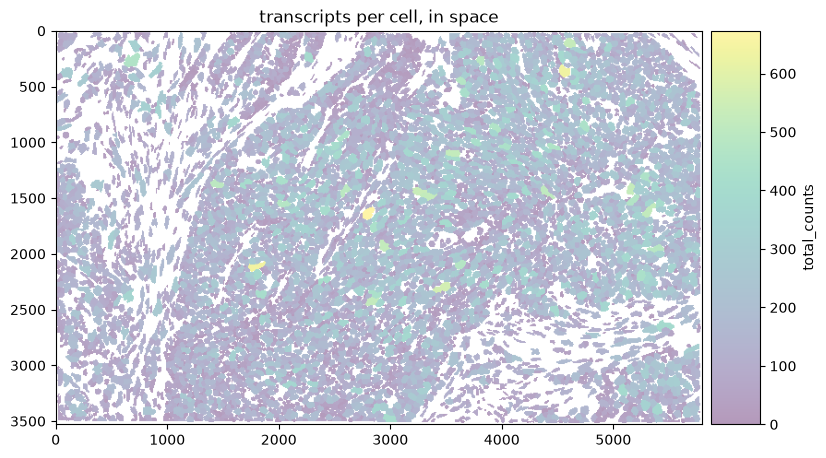

In [22]:
# This works - cell_labels is the element the table actually annotates
sdata.pl.render_labels("cell_labels", color="total_counts").pl.show(
    coordinate_systems="global", title="transcripts per cell, in space", figsize=(7, 7)
)

Whenever a colour-by fails, the question to ask is not "is the column there" but **"which
element does this table annotate"**.

The same logic governs joins. Match on `instance_key` — never assume the table rows and the
element rows are in the same order. They usually are, right up until they are not.

> **_Question:_** You filter the table down to high-quality cells and leave the labels
> element untouched. What is now inconsistent in the object, and what would you see if you
> plotted it?

## 7. Coordinate systems

Every element declares which coordinate system(s) it lives in and how to get there, via a
transformation. A microscopy image in pixel space and cell boundaries in micrometres can be
rendered together precisely because both know their way into a shared system — here called
`global`.

In [23]:
sdata.coordinate_systems

['global']

In [24]:
from spatialdata.transformations import get_transformation

# The boundaries are stored in micrometres; global is the pixel grid of the image.
# 1 pixel = 0.2125 um on Xenium, hence the scale factor.
get_transformation(sdata["cell_boundaries"], to_coordinate_system="global")

Scale (x, y)
    [4.70588235 4.70588235]

So an element's own units and the units of `global` need not be the same. `gdf.area` above was
in the element's native micrometres, which is why it agreed with the vendor's `cell_area`
column to within a few percent — the small gap is that one measures a polygon and the other
counts mask pixels.

Had the boundaries been stored in pixels instead, the same call would have returned numbers
**22 times larger**, because a scale factor of 4.7 in x and y is 4.7² in area. Areas do not
transform the way lengths do. Check which frame you are in before you trust a number with
units.

**Coordinate-system mismatch is the single most common spatial bug.** When two elements plot
in visibly wrong positions relative to each other, look here first.

## 8. Plotting with `spatialdata-plot`

`spatialdata-plot` renders by chaining `.pl.render_*` calls and finishing with `.pl.show()`.
Each call adds a layer, and the layers are composed inside the coordinate system you name —
so you never line anything up by hand.

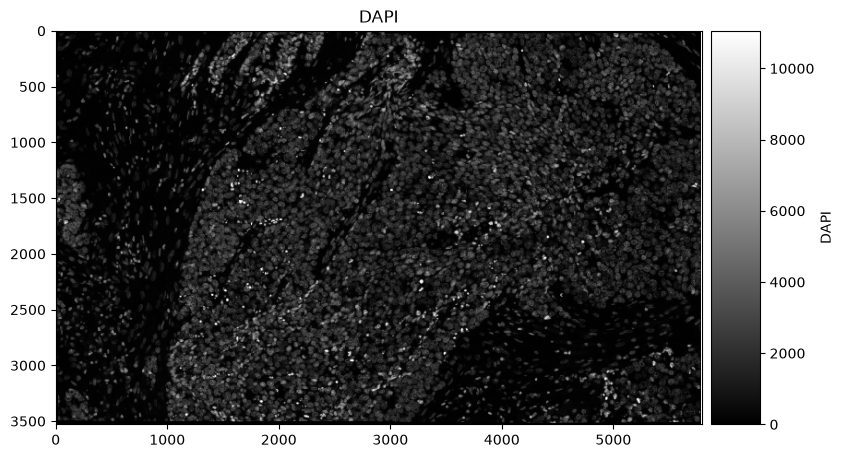

In [25]:
sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="gray").pl.show(
    coordinate_systems="global", title="DAPI", figsize=(7, 7)
)

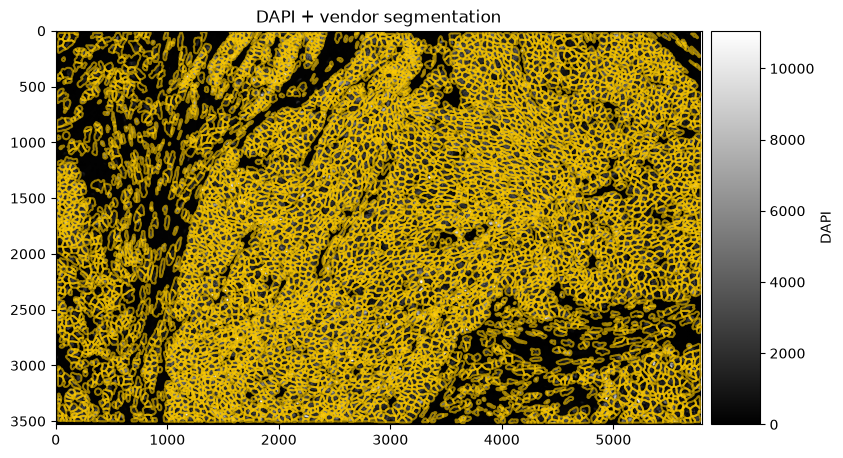

In [26]:
(
    sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="gray")
    .pl.render_shapes("cell_boundaries", fill_alpha=0, outline_alpha=0.6, outline_color="#ffcc00")
    .pl.show(coordinate_systems="global", title="DAPI + vendor segmentation", figsize=(7, 7))
)

A shapes element can also be coloured by one of **its own** columns — no table needed, since
the value lives on the geometry itself.

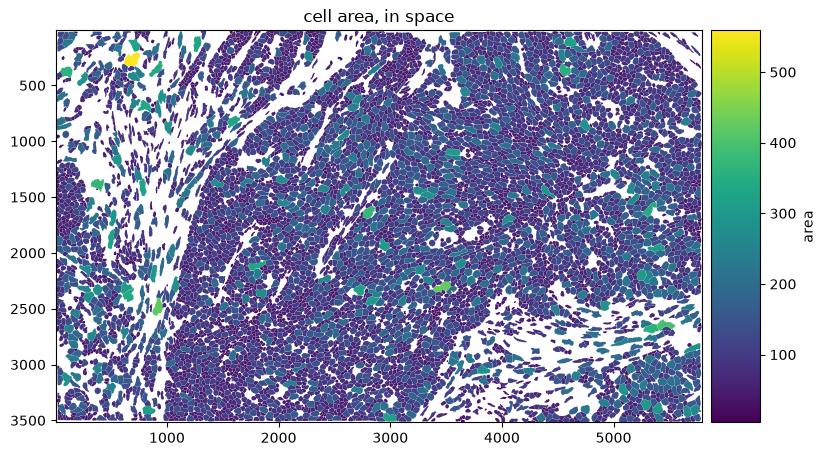

In [27]:
gdf["area"] = gdf.area

sdata.pl.render_shapes("cell_boundaries", color="area").pl.show(
    coordinate_systems="global", title="cell area, in space", figsize=(7, 7)
)

`napari-spatialdata` gives you the same object interactively, with layer toggles and manual
annotation. It is a desktop GUI and **cannot render over Remote-SSH**, so we are not running
it today. Install it locally after the course (`pip install napari-spatialdata`) and call
`Interactive(sdata)`.

## 9. Cropping

`query.bounding_box` returns a new `SpatialData` object containing only what falls inside the
box — every element, consistently, table rows included. Always say which coordinate system
the box is expressed in.

In [28]:
crop = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[1500, 1000],
    max_coordinate=[3500, 3000],
    target_coordinate_system="global",
)
print(f"{crop['table'].n_obs} cells, {len(crop['transcripts'])} transcripts")
crop

1829 cells, 272837 transcripts


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 251), (4, 125, 125)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 251), (125, 125)
│     └── 'nucleus_labels': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 251), (125, 125)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1831, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1826, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1829, 280)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

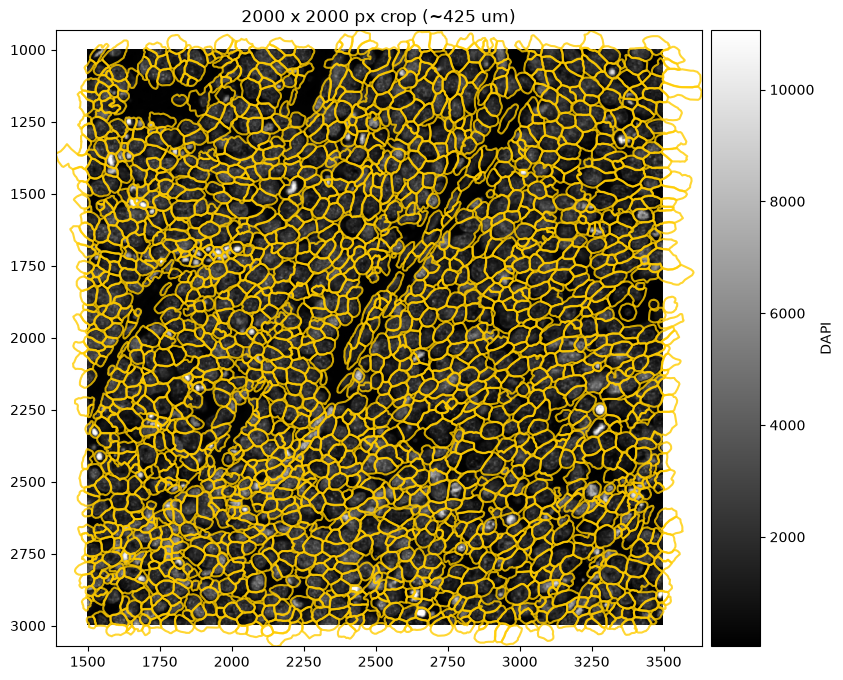

In [29]:
(
    crop.pl.render_images("morphology_focus", channel="DAPI", cmap="gray")
    .pl.render_shapes("cell_boundaries", fill_alpha=0, outline_alpha=0.8, outline_color="#ffcc00")
    .pl.show(coordinate_systems="global", title="2000 x 2000 px crop (~425 um)", figsize=(7, 7))
)

### Exercise

Work in the empty cell below. If you save anything, save it to `paths.OUT` — the data
directory is read-only.

1. Print every element name in `sdata` together with its Python type.
2. How many transcripts are **not** assigned to any cell? Stay lazy until the last moment.
   (Hint: `cell_id == "UNASSIGNED"`.) Express it as a percentage — you will meet this number
   again after the break.
3. Crop to a different 2000 x 2000 px region, and render the DAPI channel with **nucleus**
   boundaries rather than cell boundaries on top.
4. How many cells are in your crop, and how does the median `total_counts` there compare to
   the whole dataset?

> **_Question:_** Two people pick different crops and get very different median counts per
> cell. Has either of them found something biological?

In [30]:
# your answer here

## Further reading

- [SpatialData documentation](https://spatialdata.scverse.org/en/latest/) — start with the
  design overview, it is short
- [In-depth introduction to `SpatialData` objects](https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/models1.html)
- [Marconato et al. (2024), *SpatialData: an open and universal data framework for spatial omics*, Nature Methods](https://www.nature.com/articles/s41592-024-02212-x)
- `python -m spatialdata peek some_data.zarr` prints this text representation from a terminal